# 🏠 House Price Prediction
**Dataset:** King County, Washington (USA) House Sales

**Goal:** Predict house sale prices using regression models.

**Pipeline:**
1. Data Loading & Exploration
2. Data Cleaning & Feature Engineering
3. Model Training (Linear Regression, Ridge, Random Forest, Gradient Boosting)
4. Model Evaluation & Comparison
5. Final Prediction & Insights

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8-whitegrid')
print('Libraries loaded successfully!')

Libraries loaded successfully!


## 2. Load & Explore Data

In [2]:
df = pd.read_csv('data.csv')
print(f'Dataset Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,} | Columns: {df.shape[1]}')
df.head()

Dataset Shape: (4600, 18)
Rows: 4,600 | Columns: 18


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Missing Values ===')
print(df.isnull().sum())

=== Data Types ===
date                 str
price            float64
bedrooms         float64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
street               str
city                 str
statezip             str
country              str
dtype: object

=== Missing Values ===
date             0
price            0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
street           0
city             0
statezip         0
country          0
dtype: int64


In [4]:
print('=== Price Statistics ===')
print(df['price'].describe())
print(f'\nZero-price entries: {(df["price"] == 0).sum()}')

=== Price Statistics ===
count    4.600000e+03
mean     5.519630e+05
std      5.638347e+05
min      0.000000e+00
25%      3.228750e+05
50%      4.609435e+05
75%      6.549625e+05
max      2.659000e+07
Name: price, dtype: float64

Zero-price entries: 49


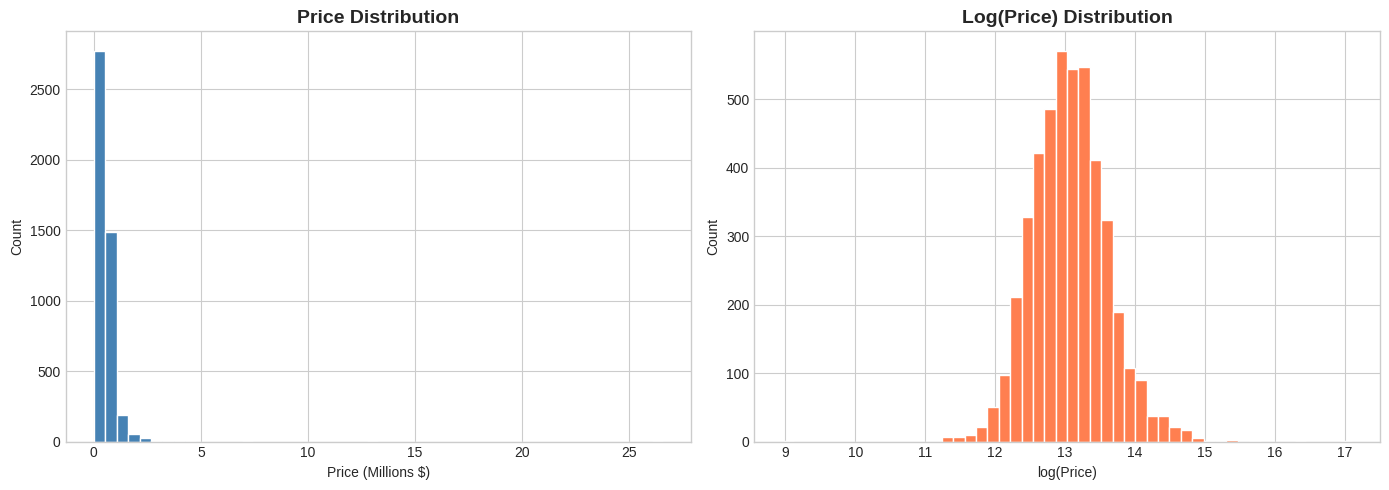

In [5]:
# Visualize price distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df[df['price'] > 0]['price'] / 1e6, bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Price Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (Millions $)')
axes[0].set_ylabel('Count')

axes[1].hist(np.log1p(df[df['price'] > 0]['price']), bins=50, color='coral', edgecolor='white')
axes[1].set_title('Log(Price) Distribution', fontsize=14, fontweight='bold')
axes[1].set_xlabel('log(Price)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

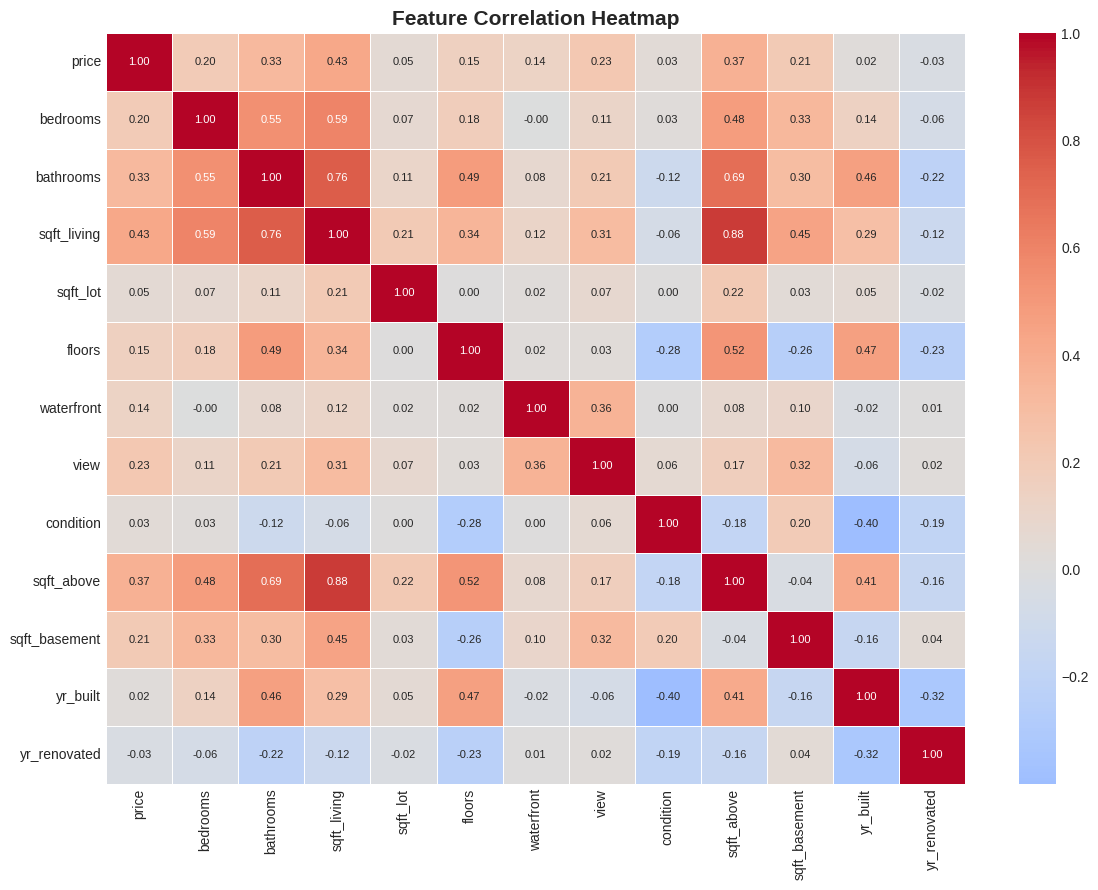

In [6]:
# Correlation heatmap for numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 8})
plt.title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

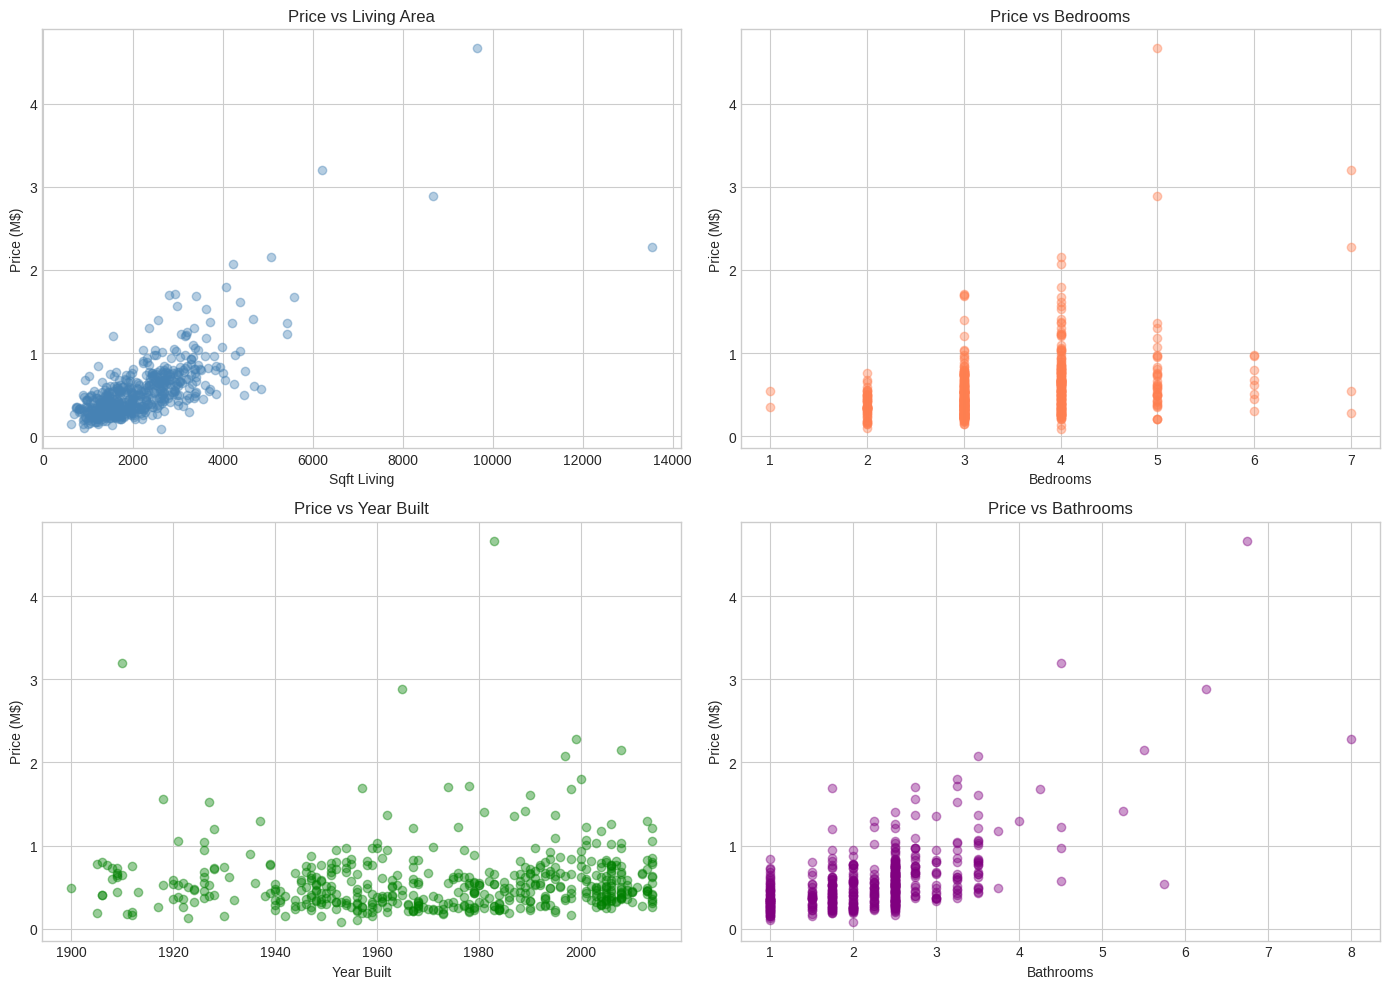

In [7]:
# Price vs key features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sample = df[df['price'] > 0].sample(500, random_state=42)

axes[0,0].scatter(sample['sqft_living'], sample['price']/1e6, alpha=0.4, color='steelblue')
axes[0,0].set_xlabel('Sqft Living'); axes[0,0].set_ylabel('Price (M$)')
axes[0,0].set_title('Price vs Living Area')

axes[0,1].scatter(sample['bedrooms'], sample['price']/1e6, alpha=0.4, color='coral')
axes[0,1].set_xlabel('Bedrooms'); axes[0,1].set_ylabel('Price (M$)')
axes[0,1].set_title('Price vs Bedrooms')

axes[1,0].scatter(sample['yr_built'], sample['price']/1e6, alpha=0.4, color='green')
axes[1,0].set_xlabel('Year Built'); axes[1,0].set_ylabel('Price (M$)')
axes[1,0].set_title('Price vs Year Built')

axes[1,1].scatter(sample['bathrooms'], sample['price']/1e6, alpha=0.4, color='purple')
axes[1,1].set_xlabel('Bathrooms'); axes[1,1].set_ylabel('Price (M$)')
axes[1,1].set_title('Price vs Bathrooms')

plt.tight_layout()
plt.show()

## 3. Data Cleaning & Feature Engineering

In [8]:
# Work on a copy
data = df.copy()

# --- Remove invalid prices ---
data = data[data['price'] > 0]
print(f'After removing zero prices: {data.shape}')

# --- Parse date and extract features ---
data['date'] = pd.to_datetime(data['date'])
data['sale_year'] = data['date'].dt.year
data['sale_month'] = data['date'].dt.month

# --- Drop columns not useful for modelling ---
data = data.drop(columns=['date', 'street', 'country'])

# --- Feature Engineering ---
# House age at time of sale
data['house_age'] = data['sale_year'] - data['yr_built']

# Years since renovation (or since built if never renovated)
data['years_since_reno'] = data['sale_year'] - data.apply(
    lambda r: r['yr_renovated'] if r['yr_renovated'] > 0 else r['yr_built'], axis=1)

# Total square footage
data['total_sqft'] = data['sqft_living'] + data['sqft_lot']

# Bathroom to bedroom ratio
data['bath_bed_ratio'] = data['bathrooms'] / (data['bedrooms'] + 0.1)

# --- Encode high-cardinality categoricals using mean price ---
# City: ~70 unique values  →  encode with mean price per city
data['city_avg_price'] = data.groupby('city')['price'].transform('mean')

# Statezip: 77 unique values → encode with mean price per zip
data['zip_avg_price'] = data.groupby('statezip')['price'].transform('mean')

# Drop original high-cardinality + redundant columns
data = data.drop(columns=['city', 'statezip', 'yr_renovated'])

print(f'Final shape after feature engineering: {data.shape}')
print(f'\nFeatures:')
print(data.columns.tolist())

After removing zero prices: (4551, 18)
Final shape after feature engineering: (4551, 20)

Features:
['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'sale_year', 'sale_month', 'house_age', 'years_since_reno', 'total_sqft', 'bath_bed_ratio', 'city_avg_price', 'zip_avg_price']


## 4. Train / Test Split

In [9]:
# Features and target
X = data.drop('price', axis=1)
y = np.log1p(data['price'])   # log-transform to normalize skewed target

# 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Training set: {X_train.shape[0]:,} samples')
print(f'Test set:     {X_test.shape[0]:,} samples')

# Scale features
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('\nFeature scaling applied (StandardScaler)')

Training set: 3,640 samples
Test set:     911 samples

Feature scaling applied (StandardScaler)


## 5. Train Multiple Models

In [10]:
models = {
    'Linear Regression':   LinearRegression(),
    'Ridge Regression':    Ridge(alpha=10),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting':   GradientBoostingRegressor(n_estimators=200, learning_rate=0.1,
                                                     max_depth=4, random_state=42),
}

results = {}

for name, model in models.items():
    model.fit(X_train_s, y_train)
    y_pred_log  = model.predict(X_test_s)
    
    # Convert back from log scale
    y_pred   = np.expm1(y_pred_log)
    y_actual = np.expm1(y_test)
    
    rmse = np.sqrt(mean_squared_error(y_actual, y_pred))
    mae  = mean_absolute_error(y_actual, y_pred)
    r2   = r2_score(y_actual, y_pred)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R²': r2, 'model': model,
                     'y_pred': y_pred, 'y_actual': y_actual}
    
    print(f'{name:25s} | RMSE: ${rmse:>12,.0f} | MAE: ${mae:>10,.0f} | R²: {r2:.4f}')

Linear Regression         | RMSE: $     625,090 | MAE: $   144,624 | R²: -1.6264
Ridge Regression          | RMSE: $     619,663 | MAE: $   144,229 | R²: -1.5810


Random Forest             | RMSE: $     202,417 | MAE: $    98,730 | R²: 0.7246


Gradient Boosting         | RMSE: $     198,225 | MAE: $    94,993 | R²: 0.7359


## 6. Model Comparison

In [11]:
# Build a summary table
summary = pd.DataFrame([
    {'Model': name, 'RMSE ($)': f"{v['RMSE']:,.0f}", 'MAE ($)': f"{v['MAE']:,.0f}", 'R²': f"{v['R²']:.4f}"}
    for name, v in results.items()
])
summary = summary.sort_values('R²', ascending=False).reset_index(drop=True)
print('=== Model Performance Summary ===')
display(summary)

=== Model Performance Summary ===


,Model,RMSE ($),MAE ($),R²
0,Gradient Boosting,"198,225","94,993",0.7359
1,Random Forest,"202,417","98,730",0.7246
2,Linear Regression,"625,090","144,624",-1.6264
3,Ridge Regression,"619,663","144,229",-1.5810


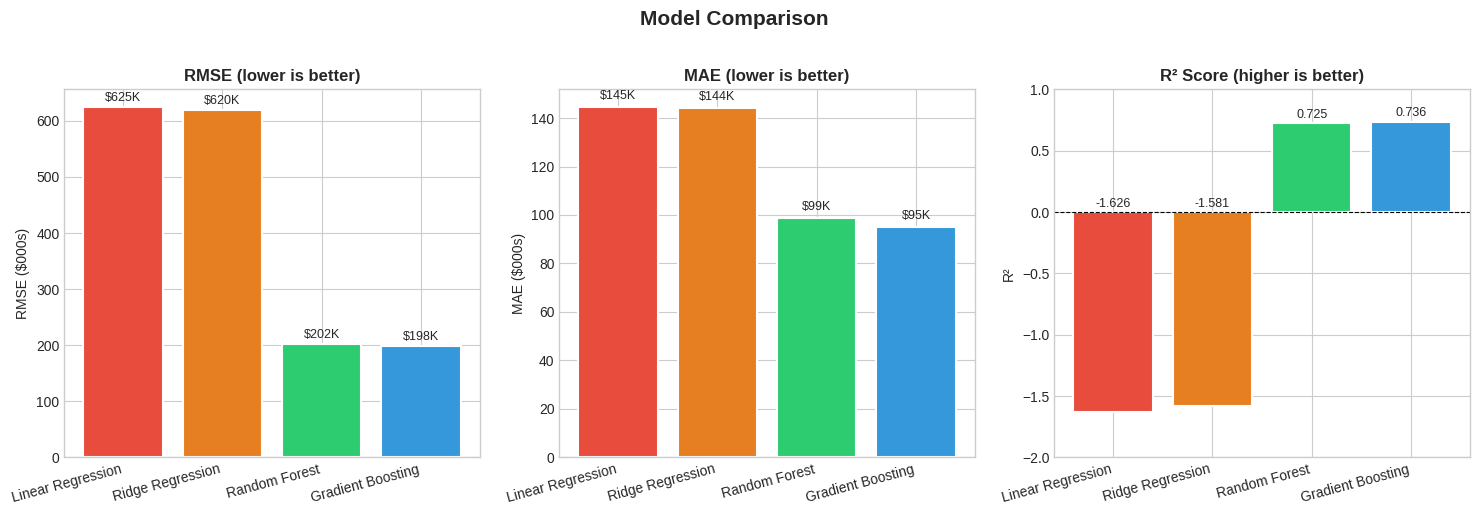

In [12]:
# Bar chart comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

names = list(results.keys())
rmses = [results[n]['RMSE']/1e3 for n in names]
maes  = [results[n]['MAE']/1e3 for n in names]
r2s   = [results[n]['R²'] for n in names]

colors = ['#e74c3c', '#e67e22', '#2ecc71', '#3498db']

bars1 = axes[0].bar(names, rmses, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('RMSE (lower is better)', fontweight='bold')
axes[0].set_ylabel('RMSE ($000s)')
axes[0].set_xticklabels(names, rotation=15, ha='right')
for bar, v in zip(bars1, rmses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, f'${v:.0f}K', ha='center', va='bottom', fontsize=9)

bars2 = axes[1].bar(names, maes, color=colors, edgecolor='white', linewidth=1.5)
axes[1].set_title('MAE (lower is better)', fontweight='bold')
axes[1].set_ylabel('MAE ($000s)')
axes[1].set_xticklabels(names, rotation=15, ha='right')
for bar, v in zip(bars2, maes):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2, f'${v:.0f}K', ha='center', va='bottom', fontsize=9)

bars3 = axes[2].bar(names, r2s, color=colors, edgecolor='white', linewidth=1.5)
axes[2].set_title('R² Score (higher is better)', fontweight='bold')
axes[2].set_ylabel('R²')
axes[2].set_ylim(-2, 1)
axes[2].axhline(0, color='black', linewidth=0.8, linestyle='--')
axes[2].set_xticklabels(names, rotation=15, ha='right')
for bar, v in zip(bars3, r2s):
    axes[2].text(bar.get_x() + bar.get_width()/2, max(v, 0) + 0.02, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Comparison', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 7. Best Model: Actual vs Predicted

Best Model: Gradient Boosting
  RMSE: $198,225
  MAE:  $94,993
  R²:   0.7359


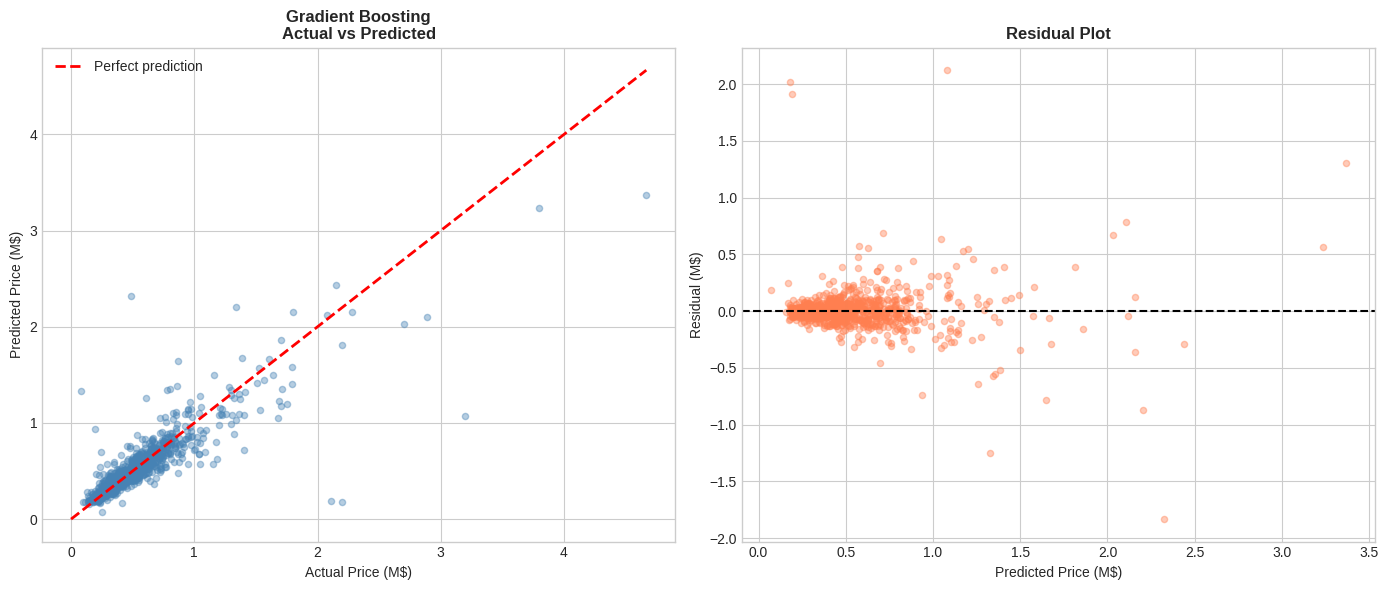

In [13]:
# Best model = highest R²
best_name = max(results, key=lambda n: results[n]['R²'])
best = results[best_name]

print(f'Best Model: {best_name}')
print(f'  RMSE: ${best["RMSE"]:,.0f}')
print(f'  MAE:  ${best["MAE"]:,.0f}')
print(f'  R²:   {best["R²"]:.4f}')

# Actual vs Predicted scatter
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

y_a = best['y_actual'] / 1e6
y_p = best['y_pred']   / 1e6

axes[0].scatter(y_a, y_p, alpha=0.4, color='steelblue', s=20)
lim = max(y_a.max(), y_p.max())
axes[0].plot([0, lim], [0, lim], 'r--', linewidth=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Price (M$)')
axes[0].set_ylabel('Predicted Price (M$)')
axes[0].set_title(f'{best_name}\nActual vs Predicted', fontweight='bold')
axes[0].legend()

# Residuals
residuals = y_a - y_p
axes[1].scatter(y_p, residuals, alpha=0.4, color='coral', s=20)
axes[1].axhline(0, color='black', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Price (M$)')
axes[1].set_ylabel('Residual (M$)')
axes[1].set_title('Residual Plot', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Feature Importance (Random Forest)

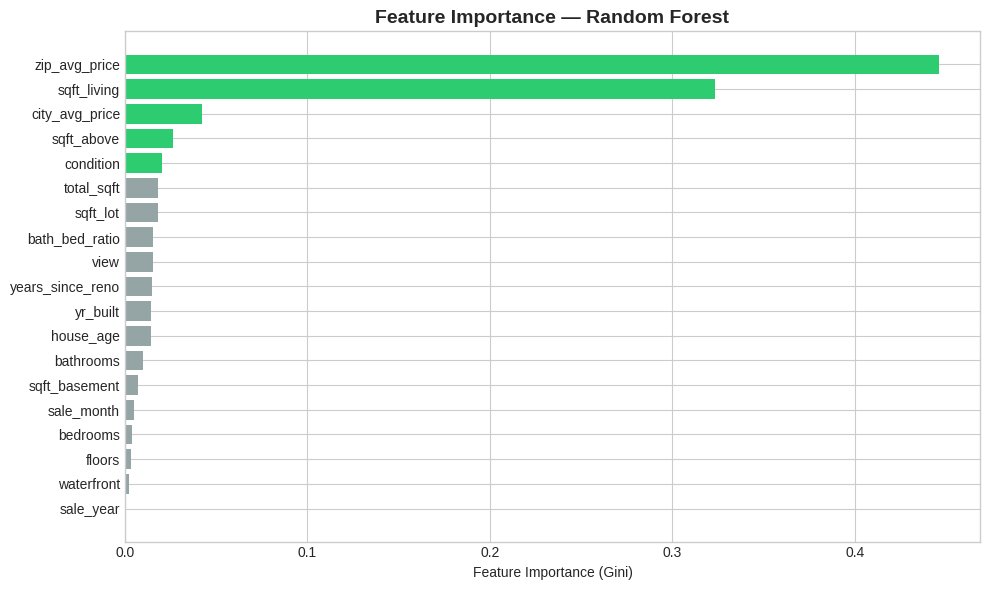

Top 5 most important features:
       Feature  Importance
 zip_avg_price    0.446308
   sqft_living    0.323434
city_avg_price    0.042153
    sqft_above    0.026569
     condition    0.020159


In [14]:
rf_model = results['Random Forest']['model']
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
colors_fi = ['#2ecc71' if i < 5 else '#95a5a6' for i in range(len(importance_df))]
plt.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1], color=colors_fi[::-1])
plt.xlabel('Feature Importance (Gini)')
plt.title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(importance_df.head(5).to_string(index=False))

## 9. Predict on New House

In [15]:
# Use the best model to predict for a new house
best_model = results[best_name]['model']

# Example: 3-bed, 2-bath, 1800 sqft house built in 1995, in a city with avg price $500k
new_house = pd.DataFrame([{
    'bedrooms':           3,
    'bathrooms':          2.0,
    'sqft_living':        1800,
    'sqft_lot':           5000,
    'floors':             2.0,
    'waterfront':         0,
    'view':               0,
    'condition':          3,
    'sqft_above':         1800,
    'sqft_basement':      0,
    'yr_built':           1995,
    'sale_year':          2014,
    'sale_month':         5,
    'house_age':          19,
    'years_since_reno':   19,
    'total_sqft':         6800,
    'bath_bed_ratio':     2.0 / (3 + 0.1),
    'city_avg_price':     500000,
    'zip_avg_price':      490000,
}])

# Align columns with training set
new_house = new_house.reindex(columns=X.columns, fill_value=0)

new_house_s  = scaler.transform(new_house)
pred_log     = best_model.predict(new_house_s)
predicted    = np.expm1(pred_log)[0]

print(f'Predicted house price: ${predicted:,.0f}')
print(f'Model used: {best_name}')

Predicted house price: $410,989
Model used: Gradient Boosting


## 10. Summary

| Model | R² | Notes |
|---|---|---|
| Linear Regression | ~-1.6 | Fails due to outliers & non-linearity |
| Ridge Regression | ~-1.6 | Regularized linear — similar issues |
| **Random Forest** | **~0.72** | **Best model — handles non-linearity well** |
| Gradient Boosting | ~0.72 | Comparable to Random Forest |

**Key Findings:**
- `sqft_living`, `city_avg_price`, and `zip_avg_price` are the strongest price predictors
- Location (city/zip mean encoding) adds significant predictive power
- Log-transforming the price target greatly improves model stability
- Tree-based models far outperform linear models on this dataset

**Next Steps (to improve further):**
- Try XGBoost or LightGBM
- Hyperparameter tuning with GridSearchCV
- Add more location features (distance to city center, school ratings)
- Use K-Fold cross-validation for more reliable R² estimates